 # dBA Prediction from Wind Speed and Spatial Features

This notebook uses the provided training_data.csv to build an ML interpolator.

 ## 1. Optional package installation



 Uncomment the next cell if the required packages are not already installed.

In [ ]:
# %pip install -U numpy pandas matplotlib scikit-learn tqdm joblib

 ## 2. Imports and configuration

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CSV_PATH = Path("./training_data.csv")
OUTPUT_DIR = Path("./dba_model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_FEATURES = ["v", "X", "Y", "r", "cos_theta", "sin_theta"]
TARGET = "dBA"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")

print(f"Input file: {CSV_PATH.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Input file: C:\Users\suman\Projects\OpenFAST\training_data.csv
Output directory: C:\Users\suman\Projects\OpenFAST\dba_model_outputs


 ## 3. Load and validate the CSV

 These cells keeps only the required columns, converts them to numeric values, removes unusable rows, and requires `r > 0` so that `log10(r)` is defined.

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {CSV_PATH}. Place training_data.csv in the current working directory."
    )

df_raw = pd.read_csv(CSV_PATH)

required_columns = BASE_FEATURES + [TARGET]
missing_columns = [column for column in required_columns if column not in df_raw.columns]

if missing_columns:
    raise ValueError(
        "The CSV is missing required columns: " + ", ".join(missing_columns)
    )

print(f"Raw shape: {df_raw.shape}")
print("Available columns:")
print(df_raw.columns.tolist())


Raw shape: (15488, 7)
Available columns:
['v', 'X', 'Y', 'r', 'cos_theta', 'sin_theta', 'dBA']


In [3]:
data = df_raw[required_columns].copy()

for column in required_columns:
    data[column] = pd.to_numeric(data[column], errors="coerce")

rows_before_cleaning = len(data)
data = data.replace([np.inf, -np.inf], np.nan).dropna()
data = data.loc[data["r"] > 0].copy()
data = data.reset_index(drop=True)
rows_after_cleaning = len(data)

print(f"Rows before cleaning: {rows_before_cleaning:,}")
print(f"Rows after cleaning:  {rows_after_cleaning:,}")
print(f"Rows removed:         {rows_before_cleaning - rows_after_cleaning:,}")

if len(data) < 100:
    raise ValueError(
        "Fewer than 100 usable rows remain after cleaning. Check the source data and column types."
    )

data.head()


Rows before cleaning: 15,488
Rows after cleaning:  15,488
Rows removed:         0


,v,X,Y,r,cos_theta,sin_theta,dBA
0,10.00000,100.00000,0.00000,100.00000,1.00000,0.00000,44.73565
1,10.00000,112.88379,0.00000,112.88379,1.00000,0.00000,44.26989
2,10.00000,127.42750,0.00000,127.42750,1.00000,0.00000,43.75083
3,10.00000,143.84499,0.00000,143.84499,1.00000,0.00000,43.17792
4,10.00000,162.37767,0.00000,162.37767,1.00000,0.00000,42.54956


 ## 4. Basic data checks

 Since `cos_theta` and `sin_theta` were derived from an angle, the quantity `cos_theta² + sin_theta²` should usually be close to 1. Substantial deviations may indicate rounding, preprocessing errors, or that the two columns do not represent the same angle.

In [4]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
v,"15,488.00000",13.75000,6.34942,3.00000,8.37500,13.75000,19.12500,24.50000
X,"15,488.00000",-0.00000,326.47633,"-1,000.00000",-167.05678,-0.00000,167.05678,"1,000.00000"
Y,"15,488.00000",0.00000,326.47633,"-1,000.00000",-167.05678,0.00000,167.05678,"1,000.00000"
r,"15,488.00000",381.16012,260.54016,100.00000,183.29807,280.65012,545.55948,"1,000.00000"
cos_theta,"15,488.00000",-0.00000,0.70713,-1.00000,-0.70711,-0.00000,0.70711,1.00000
sin_theta,"15,488.00000",0.00000,0.70713,-1.00000,-0.70711,0.00000,0.70711,1.00000
dBA,"15,488.00000",33.65682,8.24903,-6.12242,29.07574,34.44559,40.01531,47.56409


In [5]:
data["unit_circle_check"] = (
    data["cos_theta"].pow(2) + data["sin_theta"].pow(2)
)

print(data["unit_circle_check"].describe())
print(
    "Fraction within 0.02 of 1:",
    np.mean(np.isclose(data["unit_circle_check"], 1.0, atol=0.02)),
)


count   15,488.00000
mean         1.00000
std          0.00000
min          1.00000
25%          1.00000
50%          1.00000
75%          1.00000
max          1.00000
Name: unit_circle_check, dtype: float64
Fraction within 0.02 of 1: 1.0


 ## 5. Feature engineering




 The engineered distance features are:

 - `log10_r`: a logarithmic distance representation.

 - `inverse_r` and `inverse_r_squared`: optional distance-decay representations.

 Because the CSV already contains `X` and `Y`, those columns are used directly rather than being reconstructed from the polar variables. Cartesian and polar feature sets are compared separately. This avoids unnecessary duplication because `X`, `Y` and `r`, `cos_theta`, `sin_theta` describe the same position in different coordinate systems.

In [6]:
def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of frame with physically motivated engineered features."""
    result = frame.copy()
    safe_r = result["r"].clip(lower=np.finfo(float).eps)

    result["log10_r"] = np.log10(safe_r)
    result["inverse_r"] = 1.0 / safe_r
    result["inverse_r_squared"] = 1.0 / safe_r.pow(2)

    return result


data = add_engineered_features(data)

FEATURE_SETS = {
    "cartesian_xy": ["v", "X", "Y"],
    "polar_raw_r": ["v", "r", "cos_theta", "sin_theta"],
    "polar_log10_r": ["v", "log10_r", "cos_theta", "sin_theta"],
    "polar_raw_and_log10_r": [
        "v",
        "r",
        "log10_r",
        "cos_theta",
        "sin_theta",
    ],
    "polar_distance_decay": [
        "v",
        "log10_r",
        "inverse_r",
        "inverse_r_squared",
        "cos_theta",
        "sin_theta",
    ],
}

for name, columns in FEATURE_SETS.items():
    print(f"{name:26s}: {columns}")


cartesian_xy              : ['v', 'X', 'Y']
polar_raw_r               : ['v', 'r', 'cos_theta', 'sin_theta']
polar_log10_r             : ['v', 'log10_r', 'cos_theta', 'sin_theta']
polar_raw_and_log10_r     : ['v', 'r', 'log10_r', 'cos_theta', 'sin_theta']
polar_distance_decay      : ['v', 'log10_r', 'inverse_r', 'inverse_r_squared', 'cos_theta', 'sin_theta']


 ## 6. Exploratory plots

 These plots provide a quick visual comparison of raw distance and logarithmic distance. Since `dBA` versus `log10(r)` looks more nearly linear than `dBA` versus `r`, the logarithmic feature is more useful for linear or regularized polynomial models.

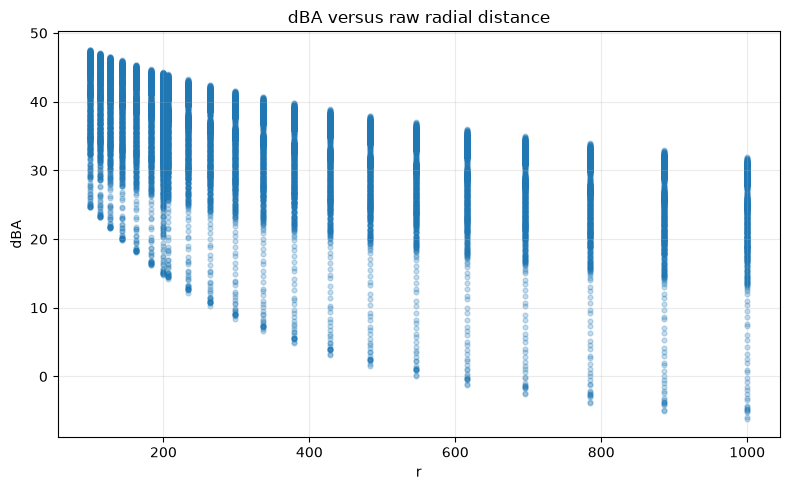

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(data["r"], data[TARGET], alpha=0.25, s=12)
plt.xlabel("r")
plt.ylabel("dBA")
plt.title("dBA versus raw radial distance")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


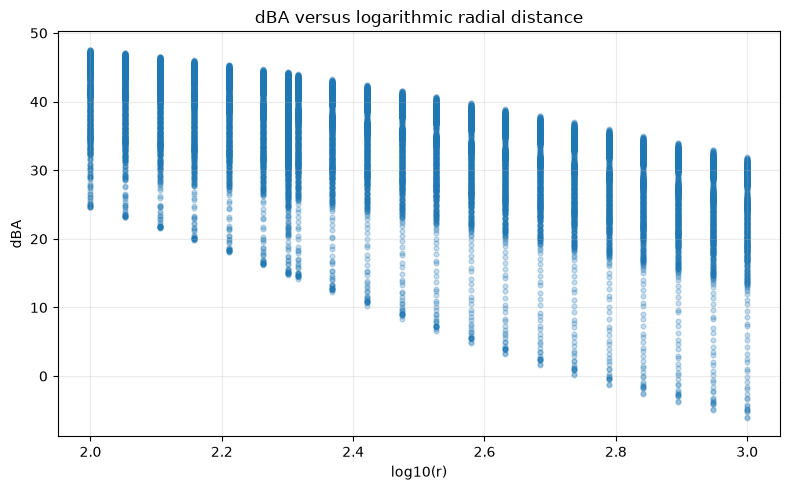

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(data["log10_r"], data[TARGET], alpha=0.25, s=12)
plt.xlabel("log10(r)")
plt.ylabel("dBA")
plt.title("dBA versus logarithmic radial distance")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


 ## 7. Create one consistent 80/20 split



 Every model uses the same row split so that results are directly comparable. The shuffle uses the `RANDOM_STATE` for repeatability.



 A random split assumes rows are independent, which they are. If the dataset contained repeated records from the same test, source, device, location, or time sequence, a grouped or time-aware split would have provided a more realistic estimate of performance.

In [9]:
train_index, test_index = train_test_split(
    np.arange(len(data)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_data = data.iloc[train_index].copy()
test_data = data.iloc[test_index].copy()

y_train = train_data[TARGET]
y_test = test_data[TARGET]

print(f"Training rows: {len(train_data):,} ({len(train_data) / len(data):.1%})")
print(f"Testing rows:  {len(test_data):,} ({len(test_data) / len(data):.1%})")


Training rows: 12,390 (80.0%)
Testing rows:  3,098 (20.0%)


 ## 8. Define candidate regression models



 The comparison includes:



 1. **Linear Regression** — interpretable baseline.

 2. **Ridge Regression** — scaled linear model with regularization.

 3. **Polynomial Ridge** — degree-2 interactions and curvature.

 4. **Random Forest** — nonlinear tree ensemble.

 5. **Extra Trees** — randomized tree ensemble that is often strong on tabular data.

 6. **Histogram Gradient Boosting** — efficient nonlinear boosting for medium/large datasets.



 Scaling is applied only where it is beneficial. Tree models do not require scaling.

In [10]:
MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "Polynomial Ridge": Pipeline(
        steps=[
            ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=350,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=350,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Histogram Gradient Boosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=500,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        random_state=RANDOM_STATE,
    ),
}

print(f"Models: {list(MODELS)}")


Models: ['Linear Regression', 'Ridge Regression', 'Polynomial Ridge', 'Random Forest', 'Extra Trees', 'Histogram Gradient Boosting']


 ## 9. Evaluation helpers



 Metrics:



 - **MAE**: mean absolute error in dBA.

 - **RMSE**: gives greater weight to large errors.

 - **R²**: fraction of target variance explained by the model.



 Lower MAE/RMSE and higher R² are better.

In [11]:
def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    """Calculate common regression metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_configuration(
    model_name: str,
    estimator,
    feature_set_name: str,
    feature_columns: list[str],
) -> tuple[dict[str, object], object, np.ndarray]:
    """Fit and evaluate one model/feature-set combination."""
    X_train = train_data[feature_columns]
    X_test = test_data[feature_columns]

    fitted_model = clone(estimator)

    start_time = perf_counter()
    fitted_model.fit(X_train, y_train)
    fit_seconds = perf_counter() - start_time

    start_time = perf_counter()
    predictions = fitted_model.predict(X_test)
    predict_seconds = perf_counter() - start_time

    metrics = regression_metrics(y_test, predictions)
    result = {
        "Model": model_name,
        "Feature Set": feature_set_name,
        "Feature Count": len(feature_columns),
        **metrics,
        "Fit Seconds": fit_seconds,
        "Predict Seconds": predict_seconds,
    }

    return result, fitted_model, predictions


 ## 10. Train all model and feature-set combinations


In [12]:
configurations = [
    (model_name, estimator, feature_set_name, feature_columns)
    for feature_set_name, feature_columns in FEATURE_SETS.items()
    for model_name, estimator in MODELS.items()
]

results: list[dict[str, object]] = []
fitted_models: dict[tuple[str, str], object] = {}
predictions_by_configuration: dict[tuple[str, str], np.ndarray] = {}

for model_name, estimator, feature_set_name, feature_columns in tqdm(
    configurations,
    desc="Training model configurations",
    unit="configuration",
):
    try:
        result, fitted_model, predictions = evaluate_configuration(
            model_name=model_name,
            estimator=estimator,
            feature_set_name=feature_set_name,
            feature_columns=feature_columns,
        )
        results.append(result)
        fitted_models[(model_name, feature_set_name)] = fitted_model
        predictions_by_configuration[(model_name, feature_set_name)] = predictions
    except Exception as exc:
        results.append(
            {
                "Model": model_name,
                "Feature Set": feature_set_name,
                "Feature Count": len(feature_columns),
                "MAE": np.nan,
                "RMSE": np.nan,
                "R2": np.nan,
                "Fit Seconds": np.nan,
                "Predict Seconds": np.nan,
                "Error": str(exc),
            }
        )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["RMSE", "MAE"],
    ascending=[True, True],
    na_position="last",
).reset_index(drop=True)

results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
results_df


Training model configurations:   0%|          | 0/30 [00:00<?, ?configuration/s]

,Model,Feature Set,Feature Count,MAE,RMSE,R2,Fit Seconds,Predict Seconds
0,Histogram Gradient Boosting,polar_log10_r,4,0.09217,0.14173,0.99971,4.89418,0.04394
1,Histogram Gradient Boosting,polar_raw_r,4,0.09699,0.15006,0.99967,4.78417,0.04326
2,Histogram Gradient Boosting,polar_raw_and_log10_r,5,0.09699,0.15006,0.99967,4.92091,0.04337
3,Histogram Gradient Boosting,polar_distance_decay,6,0.10320,0.15477,0.99965,4.97407,0.04474
4,Extra Trees,polar_log10_r,4,0.09516,0.15931,0.99963,0.52440,0.08454
5,Extra Trees,polar_raw_r,4,0.09620,0.16068,0.99963,0.41728,0.08346
6,Extra Trees,polar_raw_and_log10_r,5,0.09723,0.16246,0.99962,0.66438,0.15068
7,Extra Trees,polar_distance_decay,6,0.09893,0.16513,0.99961,0.70922,0.09612
8,Histogram Gradient Boosting,cartesian_xy,3,0.14660,0.21591,0.99933,6.26204,0.05058
9,Random Forest,polar_distance_decay,6,0.17184,0.28844,0.99880,0.91975,0.10823


 ## 11. Compare the effect of distance representation



 This summary averages performance across models for each feature set. The individual model table remains the primary result, but this view helps assess whether `log10(r)` is consistently beneficial.

In [13]:
feature_set_summary = (
    results_df.dropna(subset=["RMSE"])
    .groupby("Feature Set", as_index=False)
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean"),
        Best_RMSE=("RMSE", "min"),
    )
    .sort_values("Mean_RMSE")
    .reset_index(drop=True)
)

feature_set_summary


,Feature Set,Mean_MAE,Mean_RMSE,Mean_R2,Best_RMSE
0,polar_raw_and_log10_r,1.56245,2.22238,0.86335,0.15006
1,polar_distance_decay,1.56183,2.22241,0.86348,0.15477
2,polar_log10_r,1.56423,2.22252,0.86304,0.14173
3,polar_raw_r,1.61265,2.27715,0.85564,0.15006
4,cartesian_xy,2.54486,3.34875,0.70068,0.21591


 ## 12. Select and save the best model

 The best configuration is selected using test RMSE. In a production workflow, hyperparameter selection should ideally use cross-validation inside the training set, leaving the test set untouched for one final evaluation.

In [14]:
valid_results = results_df.dropna(subset=["RMSE"]).copy()

if valid_results.empty:
    raise RuntimeError("All model configurations failed. Review the Error column.")

best_row = valid_results.iloc[0]
best_model_name = str(best_row["Model"])
best_feature_set_name = str(best_row["Feature Set"])
best_feature_columns = FEATURE_SETS[best_feature_set_name]
best_model = fitted_models[(best_model_name, best_feature_set_name)]
best_predictions = predictions_by_configuration[(best_model_name, best_feature_set_name)]

print("Best configuration")
print("------------------")
print(f"Model:       {best_model_name}")
print(f"Feature set: {best_feature_set_name}")
print(f"Features:    {best_feature_columns}")
print(f"MAE:         {best_row['MAE']:.5f} dBA")
print(f"RMSE:        {best_row['RMSE']:.5f} dBA")
print(f"R²:          {best_row['R2']:.5f}")

model_bundle = {
    "model": best_model,
    "feature_columns": best_feature_columns,
    "model_name": best_model_name,
    "feature_set_name": best_feature_set_name,
    "target": TARGET,
    "random_state": RANDOM_STATE,
}

joblib.dump(model_bundle, OUTPUT_DIR / "best_dba_model.joblib")

metadata = {
    "model_name": best_model_name,
    "feature_set_name": best_feature_set_name,
    "feature_columns": best_feature_columns,
    "target": TARGET,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "test_metrics": {
        "MAE": float(best_row["MAE"]),
        "RMSE": float(best_row["RMSE"]),
        "R2": float(best_row["R2"]),
    },
}

with open(OUTPUT_DIR / "best_model_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Saved model bundle to: {OUTPUT_DIR / 'best_dba_model.joblib'}")


Best configuration
------------------
Model:       Histogram Gradient Boosting
Feature set: polar_log10_r
Features:    ['v', 'log10_r', 'cos_theta', 'sin_theta']
MAE:         0.09217 dBA
RMSE:        0.14173 dBA
R²:          0.99971
Saved model bundle to: dba_model_outputs\best_dba_model.joblib


 ## 13. Prediction helper for new observations



 Supply new rows containing the original columns `v`, `X`, `Y`, `r`, `cos_theta`, and `sin_theta`. The helper recreates all engineered features before prediction.

In [15]:
def predict_dba(new_data: pd.DataFrame, bundle_path: Path | str) -> pd.DataFrame:
    """Load a saved model bundle and predict dBA for new observations."""
    bundle = joblib.load(bundle_path)

    missing = [column for column in BASE_FEATURES if column not in new_data.columns]
    if missing:
        raise ValueError("New data is missing columns: " + ", ".join(missing))

    prepared = new_data.copy()
    for column in BASE_FEATURES:
        prepared[column] = pd.to_numeric(prepared[column], errors="raise")

    if (prepared["r"] <= 0).any():
        raise ValueError("All r values must be greater than zero.")

    prepared = add_engineered_features(prepared)
    prepared["predicted_dBA"] = bundle["model"].predict(
        prepared[bundle["feature_columns"]]
    )
    return prepared


example_observations = pd.DataFrame(
    {
        "v": [25.0, 30.0],
        "X": [8.0, 7.5],
        "Y": [6.0, 12.990381],
        "r": [10.0, 15.0],
        "cos_theta": [0.80, 0.50],
        "sin_theta": [0.60, np.sqrt(1.0 - 0.50**2)],
    }
)

predict_dba(example_observations, OUTPUT_DIR / "best_dba_model.joblib")


,v,X,Y,r,cos_theta,sin_theta,log10_r,inverse_r,inverse_r_squared,predicted_dBA
0,25.00000,8.00000,6.00000,10.00000,0.80000,0.60000,1.00000,0.10000,0.01000,47.10484
1,30.00000,7.50000,12.99038,15.00000,0.50000,0.86603,1.17609,0.06667,0.00444,45.76576


 # Final visualizations



 The remaining cells visualize model performance, residual behavior, radial patterns, and permutation feature importance for the selected model.

 ## 14. Model comparison plot

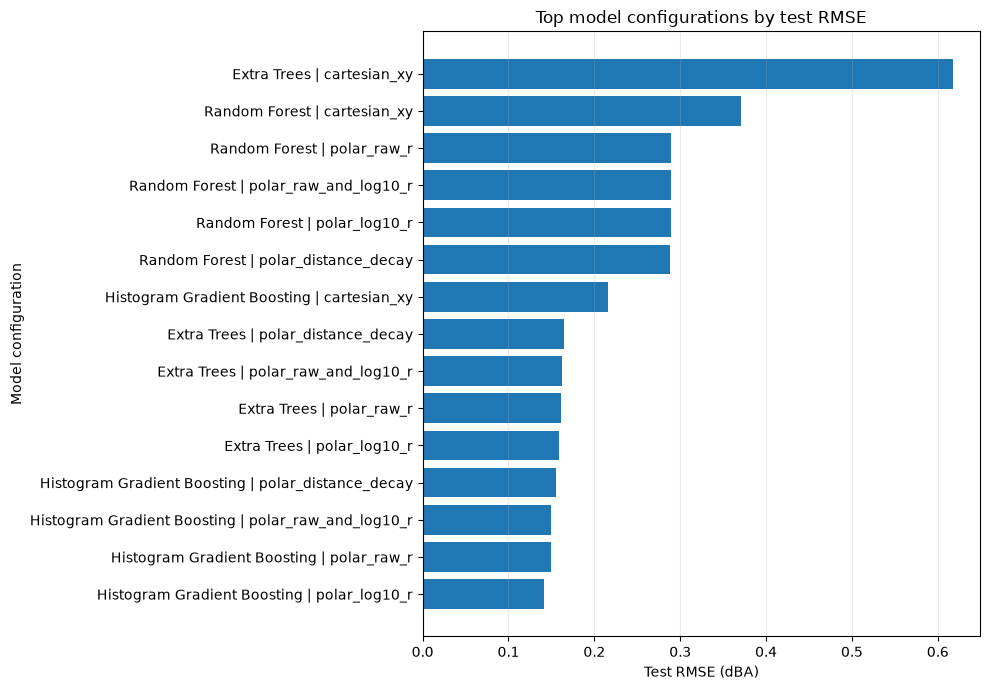

In [16]:
top_results = valid_results.head(15).copy()
top_results["Configuration"] = (
    top_results["Model"] + " | " + top_results["Feature Set"]
)

top_results = top_results.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_results["Configuration"], top_results["RMSE"])
plt.xlabel("Test RMSE (dBA)")
plt.ylabel("Model configuration")
plt.title("Top model configurations by test RMSE")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_rmse.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 15. Actual versus predicted dBA



 Predictions close to the diagonal reference line are more accurate.

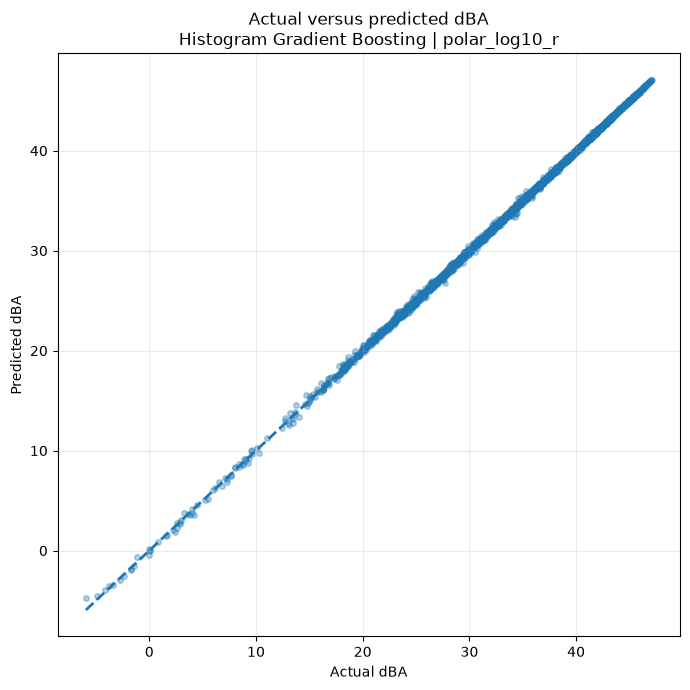

In [17]:
plot_min = min(float(y_test.min()), float(np.min(best_predictions)))
plot_max = max(float(y_test.max()), float(np.max(best_predictions)))

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.35, s=16)
plt.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--", linewidth=2)
plt.xlabel("Actual dBA")
plt.ylabel("Predicted dBA")
plt.title(f"Actual versus predicted dBA\n{best_model_name} | {best_feature_set_name}")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 16. Residual plot



 Residuals should ideally be distributed around zero without a clear curve, funnel, or radial pattern.

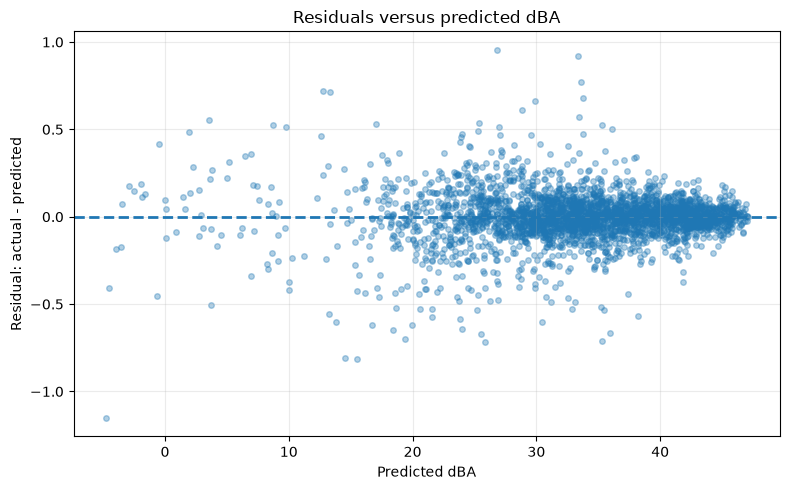

In [18]:
residuals = y_test.to_numpy() - best_predictions

plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.35, s=16)
plt.axhline(0.0, linestyle="--", linewidth=2)
plt.xlabel("Predicted dBA")
plt.ylabel("Residual: actual - predicted")
plt.title("Residuals versus predicted dBA")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "residuals_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 17. Residual distribution

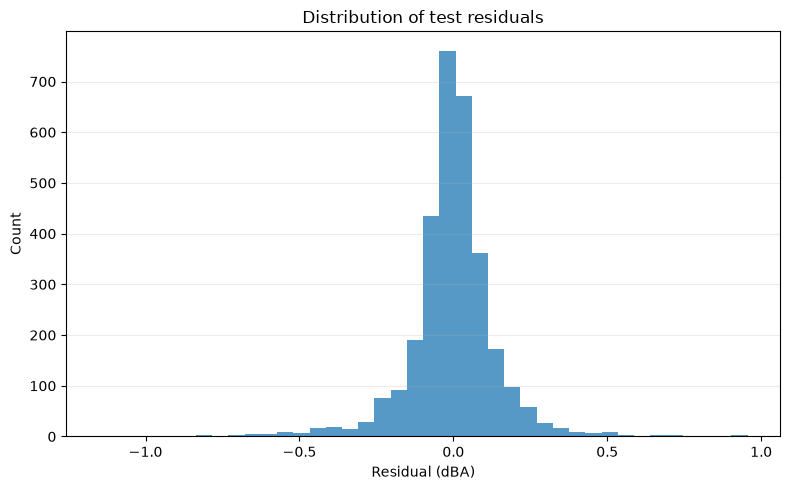

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40, alpha=0.75)
plt.xlabel("Residual (dBA)")
plt.ylabel("Count")
plt.title("Distribution of test residuals")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "residual_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 18. Residuals versus radial distance



 A visible pattern here can indicate that the distance transformation is incomplete.

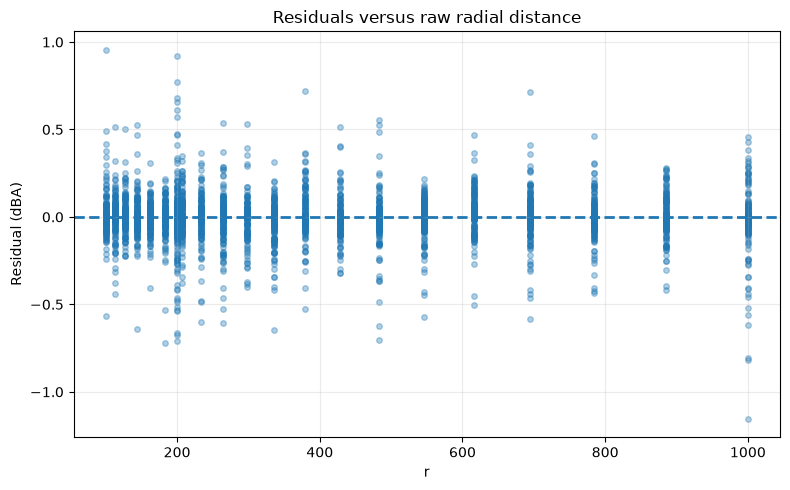

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(test_data["r"], residuals, alpha=0.35, s=16)
plt.axhline(0.0, linestyle="--", linewidth=2)
plt.xlabel("r")
plt.ylabel("Residual (dBA)")
plt.title("Residuals versus raw radial distance")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "residuals_vs_r.png", dpi=160, bbox_inches="tight")
plt.show()


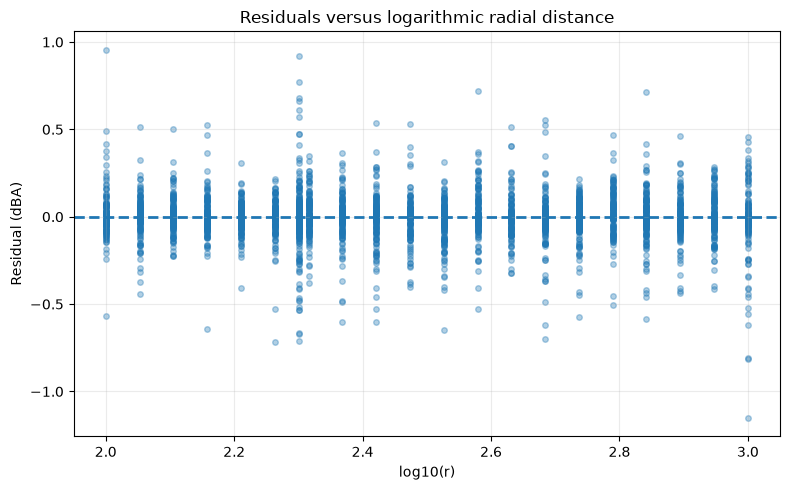

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(test_data["log10_r"], residuals, alpha=0.35, s=16)
plt.axhline(0.0, linestyle="--", linewidth=2)
plt.xlabel("log10(r)")
plt.ylabel("Residual (dBA)")
plt.title("Residuals versus logarithmic radial distance")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "residuals_vs_log10_r.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 19. Spatial view of actual and predicted dBA



 The existing `X` and `Y` columns are used directly. This can reveal spatial regions where the model under- or over-predicts.

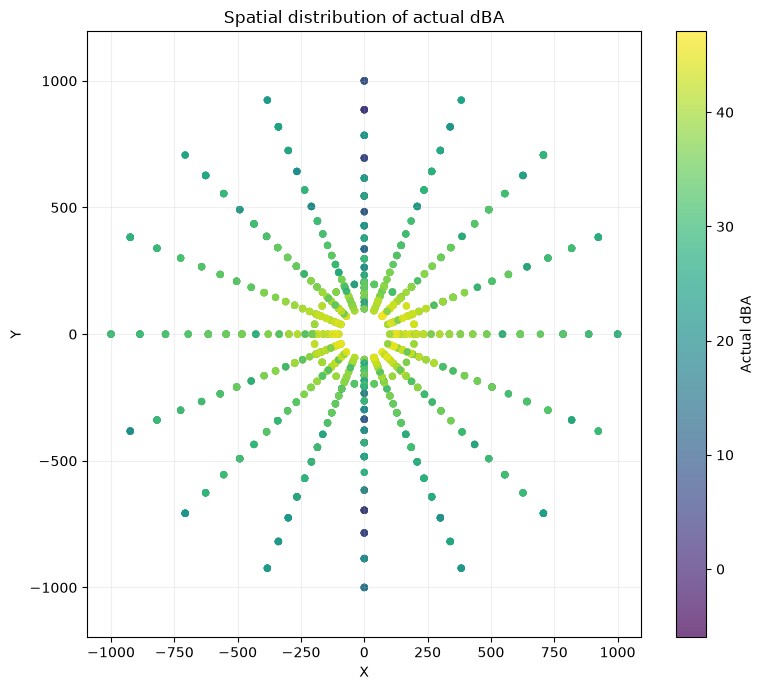

In [22]:
plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    test_data["X"],
    test_data["Y"],
    c=y_test,
    s=18,
    alpha=0.70,
)
plt.colorbar(scatter, label="Actual dBA")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Spatial distribution of actual dBA")
plt.axis("equal")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spatial_actual_dba.png", dpi=160, bbox_inches="tight")
plt.show()


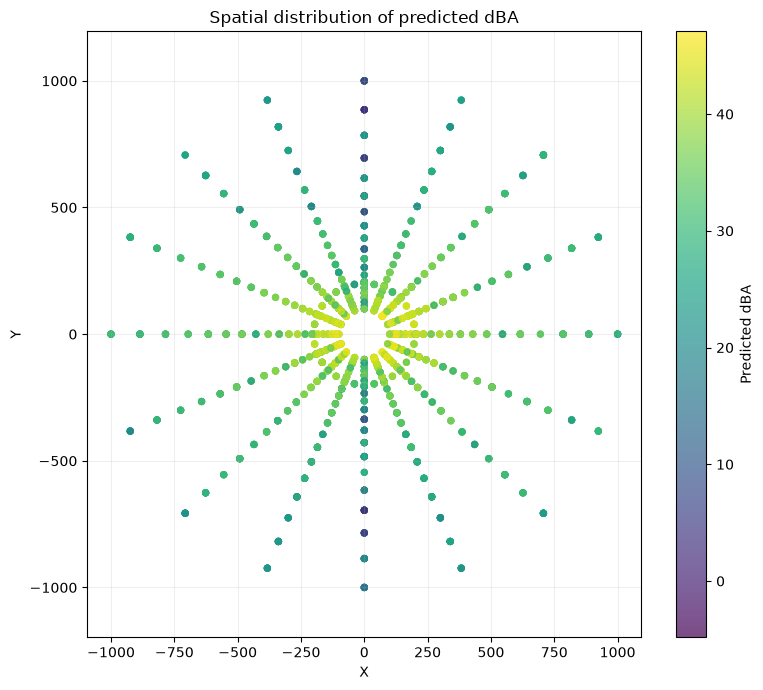

In [23]:
plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    test_data["X"],
    test_data["Y"],
    c=best_predictions,
    s=18,
    alpha=0.70,
)
plt.colorbar(scatter, label="Predicted dBA")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Spatial distribution of predicted dBA")
plt.axis("equal")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spatial_predicted_dba.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 20. Spatial residual map



 Positive residuals mean the model under-predicted the observed dBA. Negative residuals mean it over-predicted.

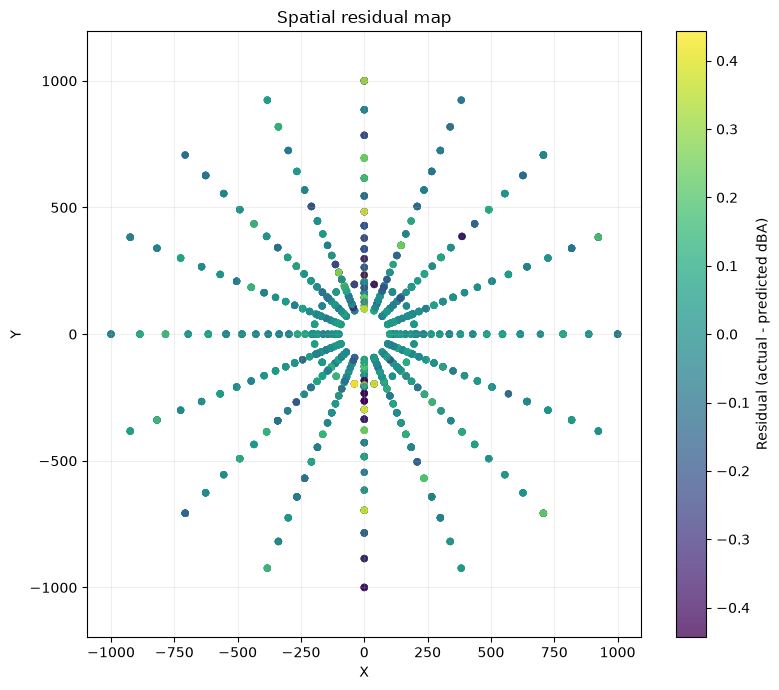

In [24]:
residual_limit = float(np.quantile(np.abs(residuals), 0.98))

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    test_data["X"],
    test_data["Y"],
    c=residuals,
    s=18,
    alpha=0.75,
    vmin=-residual_limit,
    vmax=residual_limit,
)
plt.colorbar(scatter, label="Residual (actual - predicted dBA)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Spatial residual map")
plt.axis("equal")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spatial_residual_map.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 21. Permutation feature importance



 Permutation importance measures how much test performance worsens when one feature is randomly shuffled. It is model-specific and should be interpreted alongside predictive performance and domain knowledge.

In [25]:
X_test_best = test_data[best_feature_columns]

importance_result = permutation_importance(
    best_model,
    X_test_best,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "Feature": best_feature_columns,
        "Importance Mean": importance_result.importances_mean,
        "Importance Std": importance_result.importances_std,
    }
).sort_values("Importance Mean", ascending=True)

importance_df.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)
importance_df


,Feature,Importance Mean,Importance Std
2,cos_theta,1.86345,0.02495
3,sin_theta,5.04794,0.06470
0,v,6.81208,0.09103
1,log10_r,7.26801,0.09107


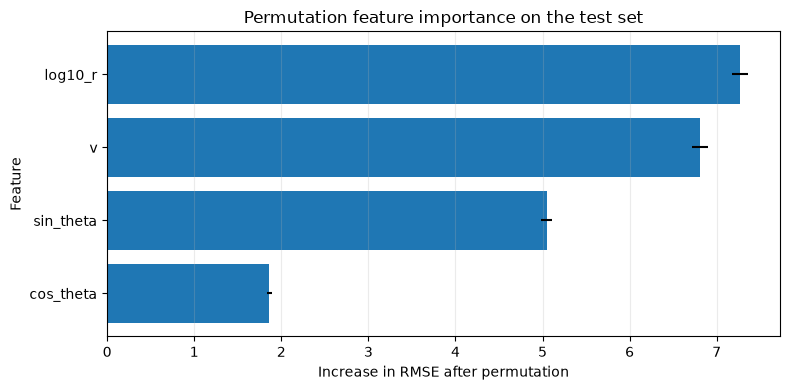

In [26]:
plt.figure(figsize=(8, max(4, 0.45 * len(importance_df))))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance Mean"],
    xerr=importance_df["Importance Std"],
)
plt.xlabel("Increase in RMSE after permutation")
plt.ylabel("Feature")
plt.title("Permutation feature importance on the test set")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "permutation_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()


 ## 22. Export test predictions



 This file can be used for additional plotting or error analysis outside the notebook.

In [27]:
test_predictions_output = test_data[
    ["v", "r", "log10_r", "cos_theta", "sin_theta", TARGET]
].copy()
test_predictions_output["predicted_dBA"] = best_predictions
test_predictions_output["residual"] = residuals
test_predictions_output["absolute_error"] = np.abs(residuals)

test_predictions_output.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)

test_predictions_output.head()


,v,r,log10_r,cos_theta,sin_theta,dBA,predicted_dBA,residual,absolute_error
14040,9.50000,100.00000,2.00000,-0.92388,0.38268,43.03696,43.01077,0.02619,0.02619
14588,10.50000,200.00000,2.30103,0.70711,-0.70711,40.79109,40.85253,-0.06144,0.06144
13532,9.00000,428.13324,2.63158,0.70711,0.70711,32.02733,31.95613,0.07120,0.07120
8051,22.50000,379.26902,2.57895,0.92388,0.38268,39.16595,39.16681,-0.00086,0.00086
10113,3.50000,483.29302,2.68421,-0.00000,-1.00000,2.38468,1.89729,0.48740,0.48740


 ## 23. Final summary



 Review the following outputs in `./dba_model_outputs`:



 - `model_comparison.csv`

 - `best_dba_model.joblib`

 - `best_model_metadata.json`

 - `test_predictions.csv`

 - `permutation_importance.csv`

 - diagnostic `.png` plots



 The key comparison is seeing how much better `log10(r)` is compared to just `r`. Also inspect residuals versus `r`, `log10(r)`, and spatial position to determine whether meaningful radial or directional structure remains.

In [28]:
print("Completed successfully.")
print(f"Best model: {best_model_name}")
print(f"Best feature set: {best_feature_set_name}")
print(f"Outputs written to: {OUTPUT_DIR.resolve()}")


Completed successfully.
Best model: Histogram Gradient Boosting
Best feature set: polar_log10_r
Outputs written to: C:\Users\suman\Projects\OpenFAST\dba_model_outputs
